<a href="https://colab.research.google.com/github/dorian-goueytes/M1_tronc_commun_stat/blob/main/PCA_impulsivit%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib as mpl
from sklearn.decomposition import PCA


## Helper function

In [2]:
def plot_cov_ellipsoid(ax, mean, cov, color='blue', alpha=0.2, scale=2.0):
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort eigenvalues/vectors (largest first)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Radii (scale controls size, like confidence level)
    radii = scale * np.sqrt(eigvals)

    # Parametric sphere
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    # Stack coordinates
    sphere = np.stack((x, y, z), axis=0).reshape(3, -1)

    # Transform sphere → ellipsoid
    ellipsoid = eigvecs @ np.diag(radii) @ sphere
    ellipsoid = ellipsoid.reshape(3, x.shape[0], x.shape[1])

    # Translate to mean
    x_e = ellipsoid[0] + mean[0]
    y_e = ellipsoid[1] + mean[1]
    z_e = ellipsoid[2] + mean[2]

    ax.plot_surface(x_e, y_e, z_e, color=color, alpha=alpha, linewidth=0)

## Loading raw data and computing scores

In [3]:
data = pd.read_csv("data.csv", sep = ';')

scores = pd.DataFrame(columns=['main_score', 'attention', 'motor', 'nonplanning', 'Q1', 'Q2'])#,'attention','motorC','self_control','sog_comp','perseverance','cog_insta'])
for part in range(0, np.shape(data)[0]):
  main_score, attention,motor,nonplanning = 0,0,0,0
  for item in range(0, np.shape(data)[1]):
    ## Attention
    if item in np.array([5,6,9,11,20,24,26,28])-1: #attention
      if item in np.array([9,20])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          attention +=4
        if data.to_numpy()[part][item] == "Occasionally":
          attention +=3
        if data.to_numpy()[part][item] == "Often":
          attention +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          attention +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          attention +=1
        if data.to_numpy()[part][item] == "Occasionally":
          attention +=2
        if data.to_numpy()[part][item] == "Often":
          attention +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          attention +=4
    ## motor
    if item in np.array([2,3,4,17,19,22,25,16,21,23,30])-1:
      if item in np.array([30])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          motor +=4
        if data.to_numpy()[part][item] == "Occasionally":
          motor +=3
        if data.to_numpy()[part][item] == "Often":
          motor +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          motor +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          motor +=1
        if data.to_numpy()[part][item] == "Occasionally":
          motor +=2
        if data.to_numpy()[part][item] == "Often":
          motor +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          motor +=4

    ## nonplanning
    if item in np.array([1,7,8,12,13,14,10,15,18,27,29])-1:
      if item in np.array([1,7,8,12,13,10,15,29])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          nonplanning +=4
        if data.to_numpy()[part][item] == "Occasionally":
          nonplanning +=3
        if data.to_numpy()[part][item] == "Often":
          nonplanning +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          nonplanning +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          nonplanning +=1
        if data.to_numpy()[part][item] == "Occasionally":
          nonplanning +=2
        if data.to_numpy()[part][item] == "Often":
          nonplanning +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          nonplanning +=4

    ### Main score
    if data.to_numpy()[part][item] == "Rarely/Never":
      main_score +=1
    if data.to_numpy()[part][item] == "Occasionally":
      main_score +=2
    if data.to_numpy()[part][item] == "Often":
      main_score +=3
    if data.to_numpy()[part][item] == "Almost Always/Always":
      main_score +=4

    if item == 30:
      if data.to_numpy()[part][item] == "Obtenir un paquet de chocolats à la fin du cours d'aujourd'hui":
        Q1 = 1
      else:
        Q1 = -1
    if item == 31:
      if data.to_numpy()[part][item] == "Obtenir un paquet de chocolats dans 12 mois":
        Q2 = 1
      else:
        Q2 = -1

  scores.loc[part] = [main_score, attention, motor, nonplanning, Q1, Q2]

## PCA

### Visualization of raw data

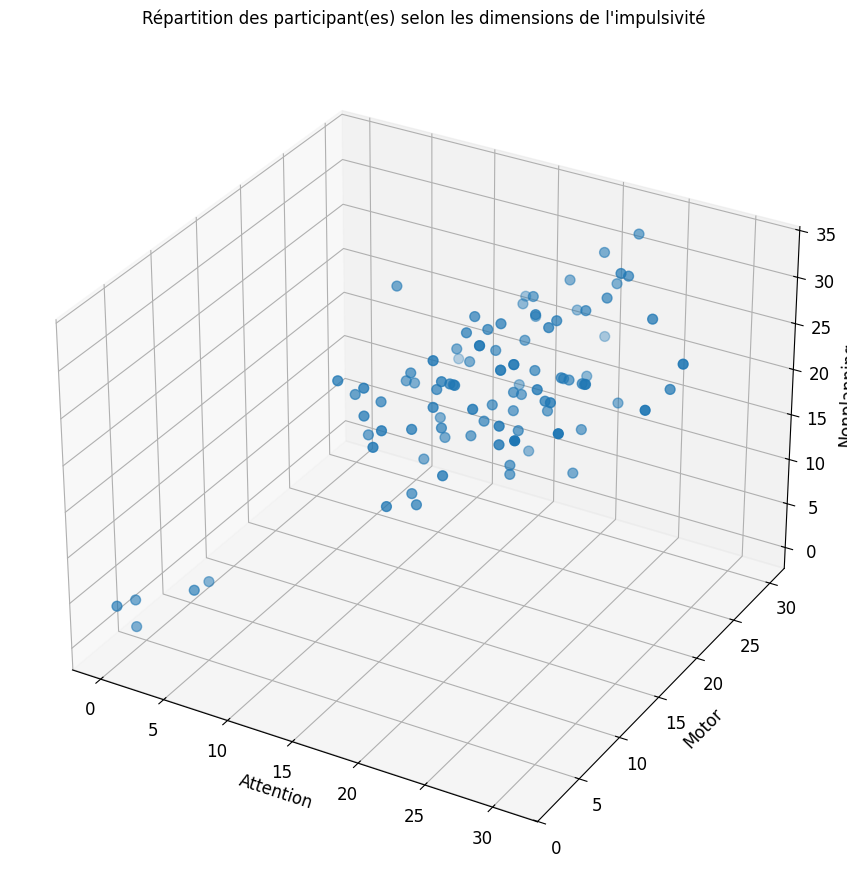

In [4]:
fig = plt.figure(figsize=(9, 9))
plt.suptitle("Répartition des participant(es) selon les dimensions de l'impulsivité")
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
ax.scatter(scores['attention'], scores['motor'], scores['nonplanning'], s =  50)
ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
plt.tight_layout()
plt.show()

## Problème : la visualisation exclut le main score

Cela signifie que nos données ne sont pas tri- mais quadri-dimensionnelles, et qu'en ignorant le main_score nous excluons une grande partie de nos données.

Comment visualiser des données en quatres dimensions?

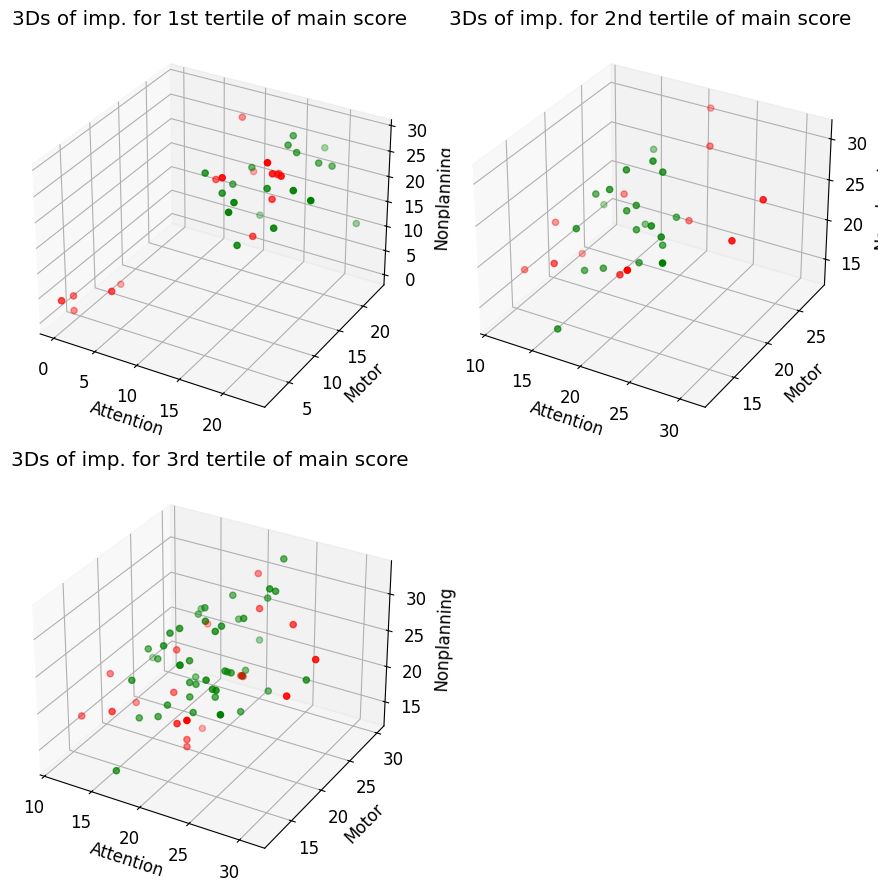

In [5]:
tertiles = scores['main_score'].quantile([1/3,2/3]).tolist()
plt.rcParams.update({'font.size': 12})

data_first_tertile = scores.loc[np.where(scores['main_score']<=tertiles[0])[0]]
data_first_tertile = data_first_tertile.reset_index()
data_second_tertile = scores.loc[np.where(np.logical_and(scores['main_score']>tertiles[0], scores['main_score']<=tertiles[1]))[0]]
data_second_tertile = data_second_tertile.reset_index()
data_third_tertile = scores.loc[np.where(scores['main_score']>tertiles[0])[0]]
data_third_tertile = data_third_tertile.reset_index()


fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(221,projection='3d')
ax.scatter(data_first_tertile['attention'].loc[np.where(data_first_tertile['Q1'] ==1)[0]], data_first_tertile['motor'].loc[np.where(data_first_tertile['Q1'] ==1)[0]], data_first_tertile['nonplanning'].loc[np.where(data_first_tertile['Q1'] ==1)[0]], color= 'g')
ax.scatter(data_first_tertile['attention'].loc[np.where(data_first_tertile['Q1'] ==-1)[0]], data_first_tertile['motor'].loc[np.where(data_first_tertile['Q1'] ==-1)[0]], data_first_tertile['nonplanning'].loc[np.where(data_first_tertile['Q1'] ==-1)[0]], color= 'r')
ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
ax.set_title('3Ds of imp. for 1st tertile of main score')

ax1 = fig.add_subplot(222,projection='3d')
ax1.scatter(data_second_tertile['attention'].loc[np.where(data_second_tertile['Q1'] ==1)[0]], data_second_tertile['motor'].loc[np.where(data_second_tertile['Q1'] ==1)[0]], data_second_tertile['nonplanning'].loc[np.where(data_second_tertile['Q1'] ==1)[0]], color= 'g')
ax1.scatter(data_second_tertile['attention'].loc[np.where(data_second_tertile['Q1'] ==-1)[0]], data_second_tertile['motor'].loc[np.where(data_second_tertile['Q1'] ==-1)[0]], data_second_tertile['nonplanning'].loc[np.where(data_second_tertile['Q1'] ==-1)[0]], color= 'r')
ax1.set_xlabel('Attention')
ax1.set_ylabel('Motor')
ax1.set_zlabel('Nonplanning')
ax1.set_title('3Ds of imp. for 2nd tertile of main score')

ax2 = fig.add_subplot(223,projection='3d')
ax2.scatter(data_third_tertile['attention'].loc[np.where(data_third_tertile['Q1'] ==1)[0]], data_third_tertile['motor'].loc[np.where(data_third_tertile['Q1'] ==1)[0]], data_third_tertile['nonplanning'].loc[np.where(data_third_tertile['Q1'] ==1)[0]], color= 'g')
ax2.scatter(data_third_tertile['attention'].loc[np.where(data_third_tertile['Q1'] ==-1)[0]], data_third_tertile['motor'].loc[np.where(data_third_tertile['Q1'] ==-1)[0]], data_third_tertile['nonplanning'].loc[np.where(data_third_tertile['Q1'] ==-1)[0]], color= 'r')
ax2.set_xlabel('Attention')
ax2.set_ylabel('Motor')
ax2.set_zlabel('Nonplanning')
ax2.set_title('3Ds of imp. for 3rd tertile of main score')
plt.tight_layout()
plt.show()

## Visualization of standardized data

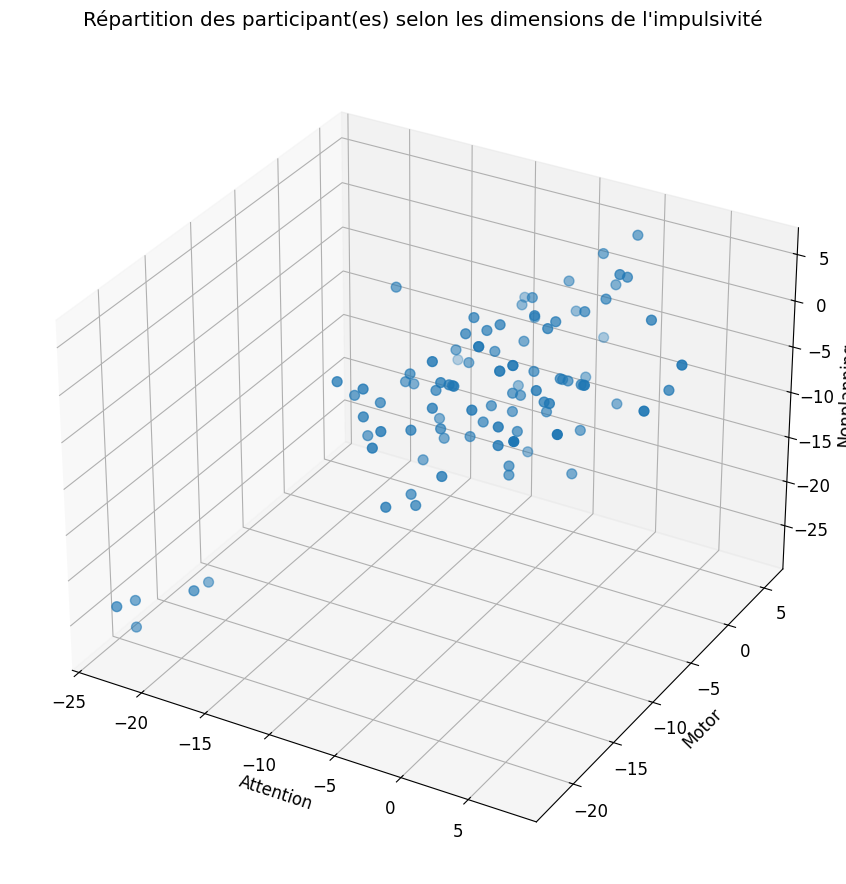

In [6]:
fig = plt.figure(figsize=(9, 9))
plt.suptitle("Répartition des participant(es) selon les dimensions de l'impulsivité")
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
attention = scores['attention'].to_numpy()
attention = (attention-np.mean(attention))-np.std(attention)
motor = scores['motor'].to_numpy()
motor = (motor-np.mean(motor))-np.std(motor)
nonplanning = scores['nonplanning'].to_numpy()
nonplanning = (nonplanning-np.mean(nonplanning))-np.std(nonplanning)

m_score = scores['main_score'].to_numpy()
m_score = (m_score-np.mean(m_score))-np.std(m_score)

ax.scatter(attention, motor, nonplanning, s =  50)
ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
plt.tight_layout()
plt.show()

## PCA and visualization

In [7]:
X = np.column_stack((m_score, attention, motor, nonplanning))

# Fit PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)
#print("Singular values:", pca.singular_values_)

Explained variance ratio: [0.86638281 0.06834873 0.03603129]


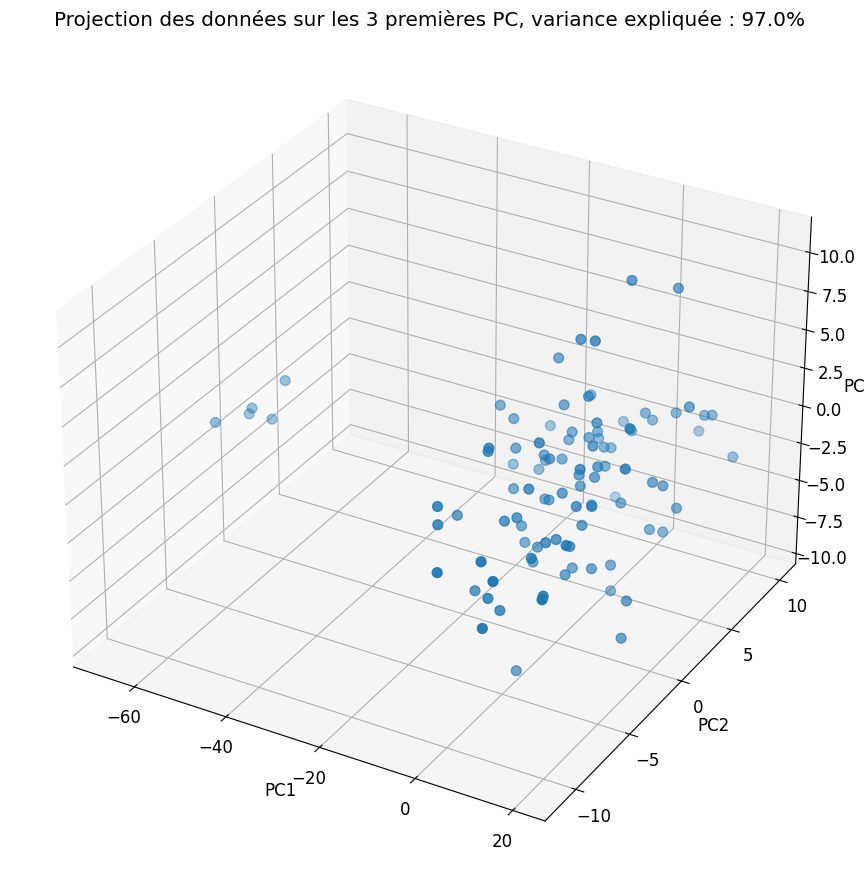

      m_score  attention     motor  nonplanning
PC1  0.887287   0.275996  0.263379     0.259192
PC2 -0.372522   0.146104  0.228465     0.887516
PC3 -0.105424   0.863157 -0.490127    -0.060175
<class 'pandas.core.frame.DataFrame'>
      m_score  attention     motor  nonplanning
PC1  0.887287   0.275996  0.263379     0.259192


In [15]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(projection='3d')


ax.scatter(X_pca[:, 0],X_pca[:, 1],X_pca[:, 2],s=50)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

exp_variance = np.round(np.sum(pca.explained_variance_ratio_),2)
plt.title("Projection des données sur les 3 premières PC, variance expliquée : "+str(exp_variance*100)+"%")
feature_names = ['m_score', 'attention', 'motor', 'nonplanning']
loadings = pd.DataFrame(pca.components_,columns=feature_names, index=[f'PC{i+1}' for i in range(len(pca.components_))])
plt.tight_layout()
plt.show()
print(loadings)
#print(loadings.loc[['PC1']])

### Interprétation des PCs :

(1) Magnitude = importance

*   Large absolute value → strong contribution
*   Near zero → negligible role

(2) Sign = direction

*   Positive → variable increases PC
*   Negative → variable opposes PC

(3) Relative comparison matters

*  You interpret within a component, not across components.

## PCA + labels

### Question 1

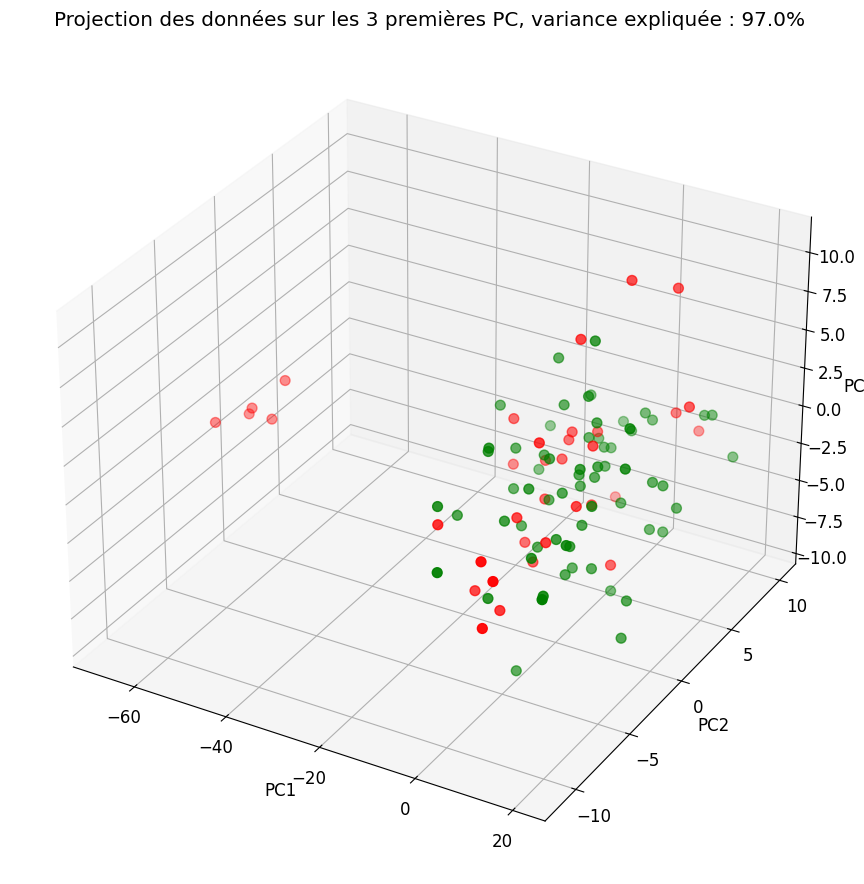

In [9]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(projection='3d')

y1 = scores['Q1'].to_numpy()
colors = np.where(y1 == 1, 'green', 'red')

ax.scatter(X_pca[:, 0],X_pca[:, 1],X_pca[:, 2],c = colors, s=50)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title("Projection des données sur les 3 premières PC, variance expliquée : "+str(exp_variance*100)+"%")
feature_names = ['m_score', 'attention', 'motor', 'nonplanning']
plt.tight_layout()
plt.show()


### Question 2

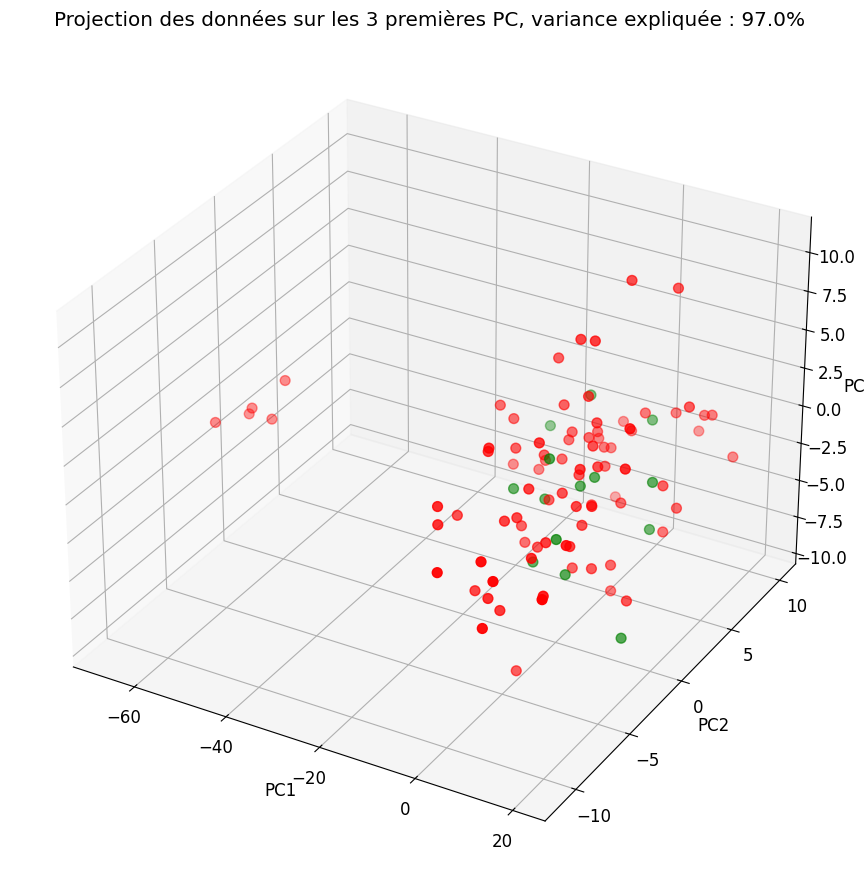

In [10]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(projection='3d')

y2 = scores['Q2'].to_numpy()
colors = np.where(y2 == 1, 'green', 'red')

ax.scatter(X_pca[:, 0],X_pca[:, 1],X_pca[:, 2],c = colors, s=50)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title("Projection des données sur les 3 premières PC, variance expliquée : "+str(exp_variance*100)+"%")
feature_names = ['m_score', 'attention', 'motor', 'nonplanning']
plt.tight_layout()
plt.show()


## PCA + Clustering

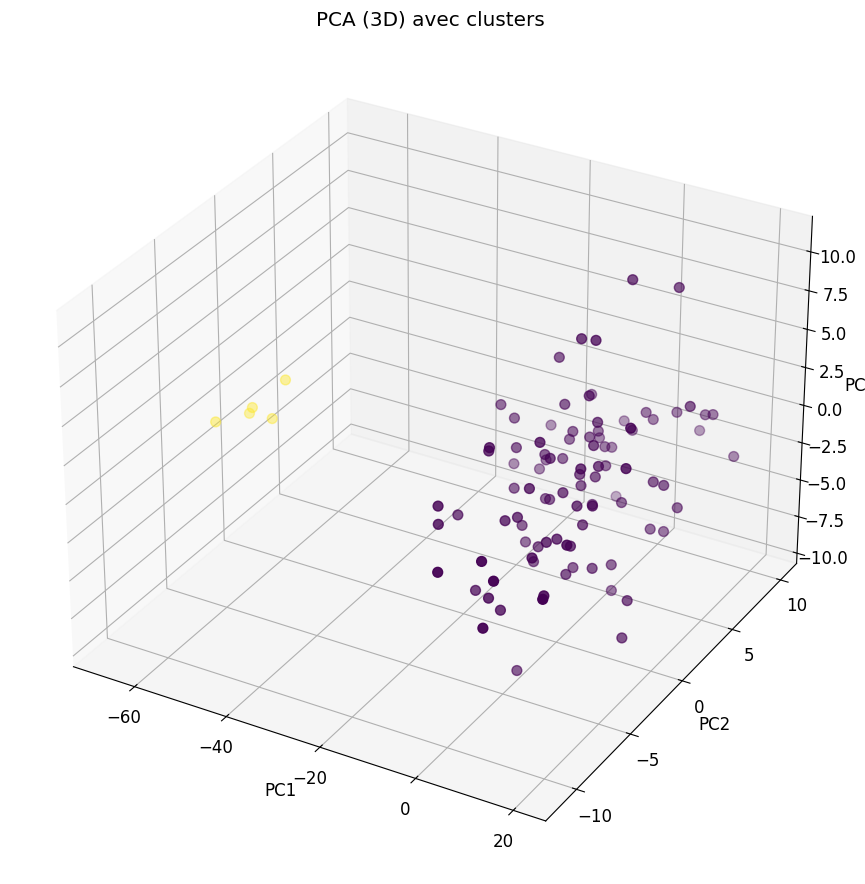

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
labels = kmeans.labels_

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(projection='3d')

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=labels,
    cmap='viridis',
    s=50
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.title("PCA (3D) avec clusters")
plt.tight_layout()
plt.show()

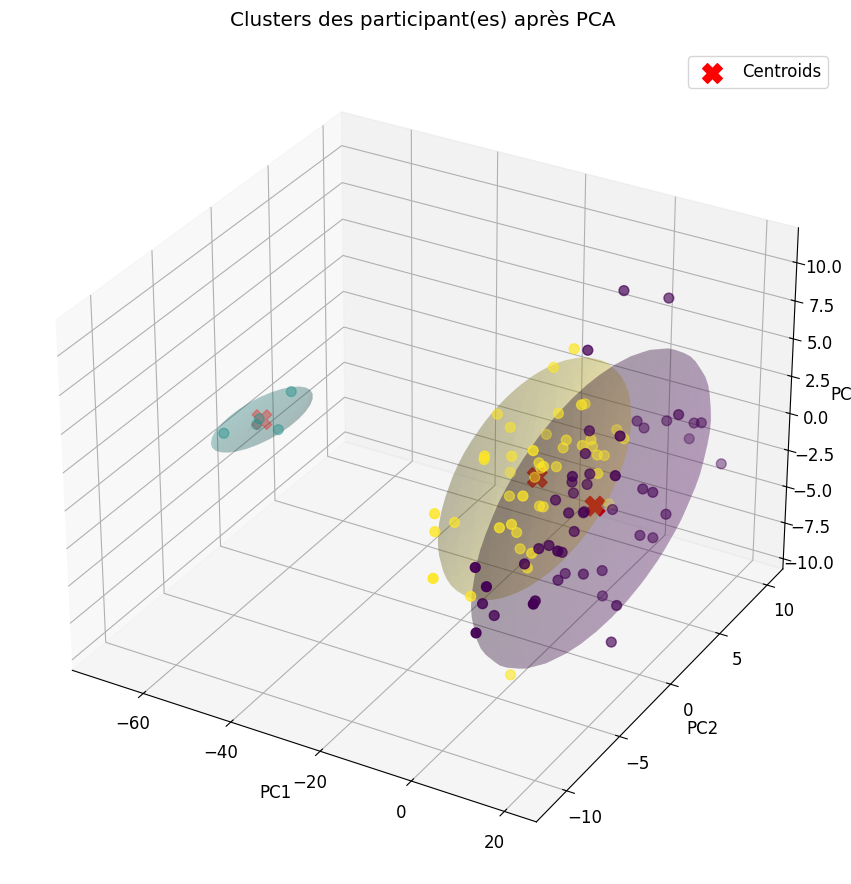

In [12]:
X  = scores[['attention', 'motor', 'nonplanning']].to_numpy()

#############################################
##### K-means and plot
n_cluster = 3 # @param {type:"slider", min:2, max:10, step:1}
kmeans = KMeans(n_clusters=n_cluster, random_state=0, n_init="auto").fit(X_pca)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Plot clustered data
fig = plt.figure(figsize=(9, 9))
plt.suptitle("Clusters des participant(es) après PCA")
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],c=labels,  cmap='viridis',s=50)
# Plot centroids
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2],c='red', s=200, marker='X', label='Centroids')



# Plot ellipsoids
cmap = mpl.colormaps['viridis']
colors = cmap(np.linspace(0, 1,n_cluster))

for i in range(kmeans.n_clusters):
    cluster_points = X_pca[labels == i]
    mean = centers[i]
    cov = np.cov(cluster_points, rowvar=False)
    plot_cov_ellipsoid(ax, mean, cov, color=colors[i], scale=2.0)


ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()

#ax.view_init(azim=180, elev=20)

plt.tight_layout()
plt.show()
